# Laboratoire 02 — Dispatch et transitions de charge

**Projet PHY-3202 — Détection entropique des pannes en cascade**
Alex Baker, superviseur : Patrick Desrosiers

---

Le carnet 01 couvrait les outils d'analyse. Celui-ci couvre le modèle de
réseau : comment la production est répartie sous contraintes, et ce qui se passe
quand on augmente la charge.

Comme précédemment, aucune logique de calcul ici. Tout vient du paquet
`cascade_entropy`, couvert par 105 tests.

**Au programme**

1. Le dispatch, et un cas vérifiable à la main
2. Un réseau chargé, ligne par ligne
3. Les deux transitions du modèle
4. Ce que voit l'entropie de répartition
5. Une avarie de ligne, et pourquoi l'arbre a ses limites

In [1]:
import numpy as np

from cascade_entropy import figures
from cascade_entropy.dispatch import demande_uniforme, resoudre
from cascade_entropy.entropie import entropie_repartition, nombre_effectif
from cascade_entropy.reseau import (
    Reseau,
    arbre,
    limites_par_niveau,
    matrice_de_flux,
)

figures.appliquer_style()

GRAINE = 20260915
P_C = 2623.9            # capacité totale de production, valeur publiée
CIBLE_SECONDE = 1.45    # niveau de charge visé pour la saturation des lignes

rng = np.random.default_rng(GRAINE)

---
## 1. Le dispatch

Étant donné une demande, le dispatch décide quel générateur produit combien et
quelle charge est servie. Le problème est linéaire :

$$\min \;\; \sum_i G_i - W \sum_j L_j$$

sous quatre contraintes — capacités de production, demande non dépassée,
équilibre global, et limites de transport. Avec $W = 100$, servir la charge
rapporte cent fois plus que produire ne coûte : le solveur sert donc le maximum
possible, et coupe le moins possible quand il ne peut pas tout servir.

Avant d'appliquer ça à 46 nœuds, un cas qu'on peut vérifier de tête.

In [2]:
chaine = Reseau(
    n_noeuds=3,
    lignes=np.array([[0, 1], [1, 2]]),
    reactances=np.array([1.0, 1.0]),
    generateurs=np.array([0]),
    charges=np.array([1, 2]),
    limites=np.array([10.0, 10.0]),
    reference=0,
)

solution = resoudre(chaine, demande=np.array([1.0, 1.0]),
                    puissance_max=np.array([10.0]))

print("Chaîne 0—1—2, générateur en 0, deux charges d'une unité")
print(f"  production      : {solution.production}")
print(f"  charge servie   : {solution.charge_servie}")
print(f"  flux            : {solution.flux}   (attendu [2, 1])")
print(f"  délestage       : {solution.delestage_total}")

Chaîne 0—1—2, générateur en 0, deux charges d'une unité
  production      : [2.]
  charge servie   : [1. 1.]
  flux            : [2. 1.]   (attendu [2, 1])
  délestage       : 0.0


Le générateur produit 2, la première ligne porte les deux charges, la seconde
n'en porte qu'une. C'est le seul résultat physiquement possible, et le solveur
le retrouve.

Maintenant, la même chose avec la ligne amont plafonnée à 1,5.

In [4]:
chaine_limitee = Reseau(
    n_noeuds=3,
    lignes=np.array([[0, 1], [1, 2]]),
    reactances=np.array([1.0, 1.0]),
    generateurs=np.array([0]),
    charges=np.array([1, 2]),
    limites=np.array([1.5, 10.0]),
    reference=0,
)

limitee = resoudre(chaine_limitee, demande=np.array([1.0, 1.0]),
                   puissance_max=np.array([10.0]))

print(f"  flux            : {limitee.flux}")
print(f"  charge servie   : {limitee.charge_servie}")
print(f"  délestage       : {limitee.delestage_total}   (attendu 0,5)")
print(f"  M_max           : {limitee.taux_maximal}")
print(f"  lignes saturées : {limitee.lignes_saturees}")

  flux            : [1.5 1. ]
  charge servie   : [0.5 1. ]
  délestage       : 0.5   (attendu 0,5)
  M_max           : 1.0
  lignes saturées : [0]


**Le point le plus important du module.** La ligne est à 1,5 sur une limite de
1,5, donc son taux de charge vaut exactement 1. Elle est **saturée**, pas en
dépassement — et elle ne le sera jamais, puisque la contrainte est dure dans le
problème d'optimisation.

C'est ce qui définit la surcharge dans le modèle de cascade : une ligne collée
contre sa limite. Le module `cascade` fera tomber ces lignes-là avec une
probabilité $p_1$, jamais des lignes en dépassement, qui n'existent pas.

---
## 2. Un réseau chargé

Passons au réseau à 46 nœuds. Les capacités de lignes décroissent avec la
profondeur de l'arbre, puisqu'une ligne proche de la racine doit écouler la
puissance de tout son sous-arbre.

In [5]:
reseau = arbre(4)
A = matrice_de_flux(reseau)
p_max = np.full(reseau.generateurs.size, P_C / reseau.generateurs.size)

# L'échelle des capacités est le seul paramètre libre : elle est fixée pour que
# la saturation apparaisse au niveau de charge rapporté dans la littérature.
base = limites_par_niveau(reseau)
facteur = resoudre(reseau, demande_uniforme(reseau, CIBLE_SECONDE * P_C),
                   limites=base, puissance_max=p_max, A=A).taux_maximal
limites = base * facteur

print(f"{reseau.n_noeuds} nœuds, {reseau.n_lignes} lignes, "
      f"{reseau.generateurs.size} générateurs")
print(f"capacités par niveau : {np.unique(limites).round(1)}")
print(f"facteur d'échelle appliqué aux valeurs publiées : {facteur:.4f}")

46 nœuds, 45 lignes, 12 générateurs
capacités par niveau : [111.9 231.3 470.  947.4]
facteur d'échelle appliqué aux valeurs publiées : 0.0607


délestage   : 0.0
M_max       : 0.657
taux moyen  : 0.455


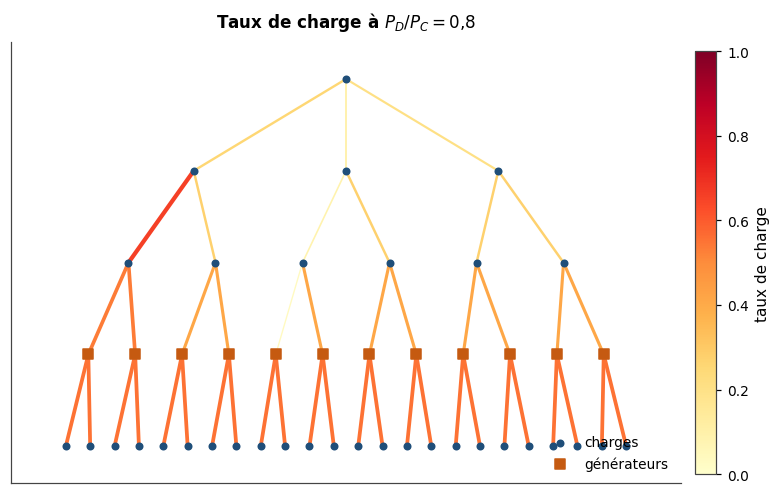

In [6]:
charge_moderee = resoudre(reseau, demande_uniforme(reseau, 0.8 * P_C),
                          limites=limites, puissance_max=p_max, A=A)

figures.reseau_en_arbre(reseau, taux=charge_moderee.taux_de_charge,
                        titre="Taux de charge à $P_D/P_C = 0{,}8$");

print(f"délestage   : {charge_moderee.delestage_total:.1f}")
print(f"M_max       : {charge_moderee.taux_maximal:.3f}")
print(f"taux moyen  : {charge_moderee.taux_de_charge.mean():.3f}")

---
## 3. Les deux transitions

On augmente maintenant la demande à profil fixe, et on observe.

In [7]:
RATIOS = np.linspace(0.2, 2.0, 55)

colonnes = {cle: [] for cle in
            ("servie", "delestage", "taux_max", "taux_moyen", "saturees", "lignes_eff")}

for ratio in RATIOS:
    s = resoudre(reseau, demande_uniforme(reseau, ratio * P_C),
                 limites=limites, puissance_max=p_max, A=A)
    colonnes["servie"].append(s.charge_servie.sum() / P_C)
    colonnes["delestage"].append(s.delestage_total / (ratio * P_C))
    colonnes["taux_max"].append(s.taux_maximal)
    colonnes["taux_moyen"].append(s.taux_de_charge.mean())
    colonnes["saturees"].append(s.lignes_saturees.size)
    colonnes["lignes_eff"].append(nombre_effectif(s.flux))

balayage = {cle: np.array(v) for cle, v in colonnes.items()}
seuils = {"production": 1.0, "transport": CIBLE_SECONDE}

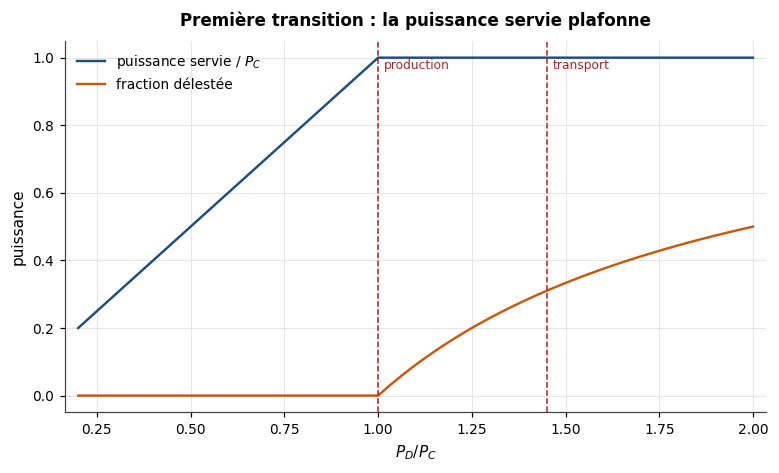

In [8]:
figures.transitions(
    RATIOS,
    {"puissance servie / $P_C$": balayage["servie"],
     "fraction délestée": balayage["delestage"]},
    seuils, ylabel="puissance",
    titre="Première transition : la puissance servie plafonne",
);

Le délestage démarre exactement à $P_D/P_C = 1$, et la puissance servie
plafonne définitivement. Aucun réglage n'intervient ici : c'est la conséquence
directe de la contrainte de capacité de production.

Au-delà, la fraction délestée vaut exactement $(r-1)/r$, ce qui se vérifie sur
les valeurs ci-dessous.

In [9]:
for ratio in (1.2, 1.5, 2.0):
    s = resoudre(reseau, demande_uniforme(reseau, ratio * P_C),
                 limites=limites, puissance_max=p_max, A=A)
    mesure = s.delestage_total / (ratio * P_C)
    print(f"P_D/P_C = {ratio}  →  délesté {mesure:.4f}, attendu {(ratio-1)/ratio:.4f}")

P_D/P_C = 1.2  →  délesté 0.1667, attendu 0.1667
P_D/P_C = 1.5  →  délesté 0.3333, attendu 0.3333
P_D/P_C = 2.0  →  délesté 0.5000, attendu 0.5000


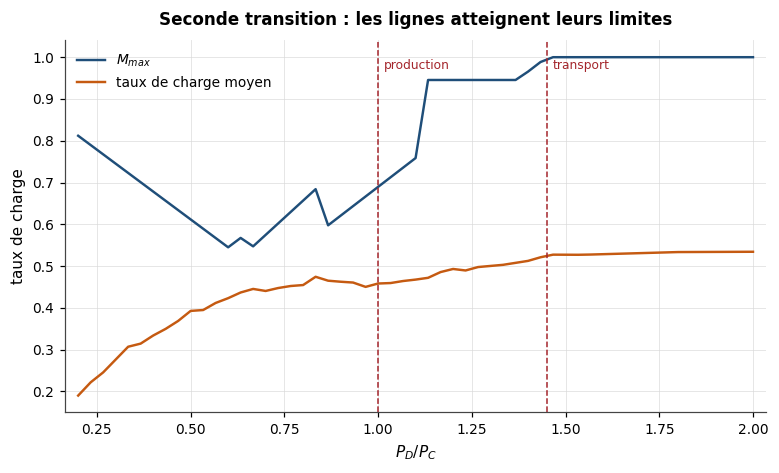

In [10]:
figures.transitions(
    RATIOS,
    {"$M_{max}$": balayage["taux_max"],
     "taux de charge moyen": balayage["taux_moyen"]},
    seuils, ylabel="taux de charge",
    titre="Seconde transition : les lignes atteignent leurs limites",
);

**Voici l'observation qui n'a pas été programmée.**

Au-delà de la première transition, la puissance totale servie ne bouge plus.
Elle est rigoureusement constante. Et pourtant $M_{\max}$ continue de monter,
jusqu'à atteindre 1.

Comment une puissance constante peut-elle charger davantage les lignes ? Parce
que le délestage n'est pas uniforme. Le solveur coupe là où c'est le moins
coûteux compte tenu des contraintes, donc la **répartition** de la puissance
entre les charges change même quand le **total** reste fixe. Les flux suivent
cette redistribution.

C'est exactement le mécanisme que Carreras invoque pour expliquer l'existence
d'une seconde transition. Il émerge ici du modèle, il n'y a pas été mis.

---
## 4. Ce que voit l'entropie de répartition

L'observable retenue dans SO2 est l'entropie de la distribution des flux. Son
exponentielle donne le **nombre effectif de lignes** portant le réseau : si
quarante-cinq lignes se partagent la puissance également, la valeur est 45 ; si
une seule porte tout, elle est 1.

à P_D/P_C = 0,2 : 22.9 lignes effectives
au maximum      : 44.9
à P_D/P_C = 2,0 : 25.9 lignes effectives


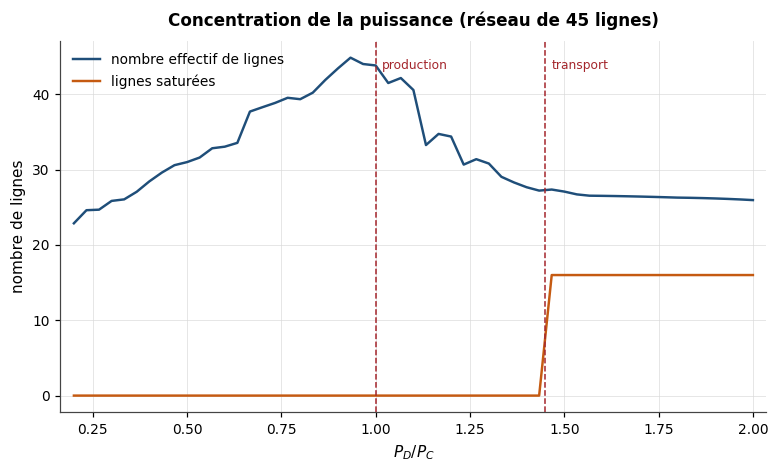

In [11]:
figures.transitions(
    RATIOS,
    {"nombre effectif de lignes": balayage["lignes_eff"],
     "lignes saturées": balayage["saturees"]},
    seuils, ylabel="nombre de lignes",
    titre=f"Concentration de la puissance (réseau de {reseau.n_lignes} lignes)",
);

print(f"à P_D/P_C = 0,2 : {balayage['lignes_eff'][0]:.1f} lignes effectives")
print(f"au maximum      : {balayage['lignes_eff'].max():.1f}")
print(f"à P_D/P_C = 2,0 : {balayage['lignes_eff'][-1]:.1f} lignes effectives")

La courbe monte jusqu'à frôler 45 juste avant la première transition — la
puissance y est répartie de façon presque parfaitement homogène — puis chute
nettement lorsque le réseau se charge. La puissance se concentre.

C'est la première fois que les deux fils du projet se touchent : une mesure
informationnelle, développée et validée sans aucune donnée électrique, répond
visiblement au niveau de stress du réseau.

**Attention à ne pas conclure trop vite.** Cette courbe ne démontre rien encore.
Il faudra vérifier qu'elle dit quelque chose que $M_{\max}$ ou la charge moyenne
ne disent pas déjà. C'est précisément l'objet du sous-objectif SO3.

$P_D/P_C = 0.5$ : moyenne 0.393, max 0.612, entropie 0.988
$P_D/P_C = 1.0$ : moyenne 0.458, max 0.690, entropie 0.950
$P_D/P_C = 1.5$ : moyenne 0.527, max 1.000, entropie 0.875


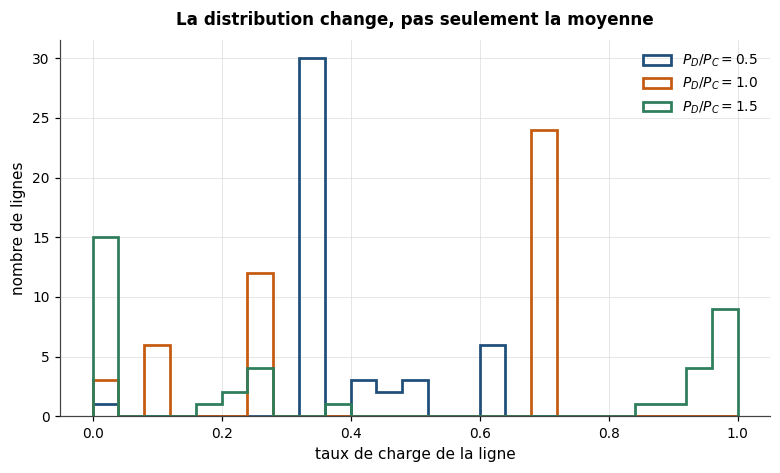

In [12]:
cas = {}
for ratio in (0.5, 1.0, 1.5):
    s = resoudre(reseau, demande_uniforme(reseau, ratio * P_C),
                 limites=limites, puissance_max=p_max, A=A)
    cas[f"$P_D/P_C = {ratio}$"] = s.taux_de_charge

figures.distributions_taux(cas, titre="La distribution change, pas seulement la moyenne");

for nom, taux in cas.items():
    print(f"{nom} : moyenne {taux.mean():.3f}, max {taux.max():.3f}, "
          f"entropie {entropie_repartition(taux, normaliser=True):.3f}")

Deux réseaux peuvent avoir un taux de charge moyen voisin et des distributions
très différentes. C'est cette différence que l'entropie capte et que la moyenne
manque.

---
## 5. Une avarie de ligne

Aperçu du module suivant. Une ligne tombe : sa capacité passe à zéro, et on
relance le dispatch.

ligne perdue : 3, reliant les nœuds [1 4]
délestage    : 0.0  →  0.0
M_max        : 0.657  →  0.569
lignes eff.  : 39.3  →  39.7


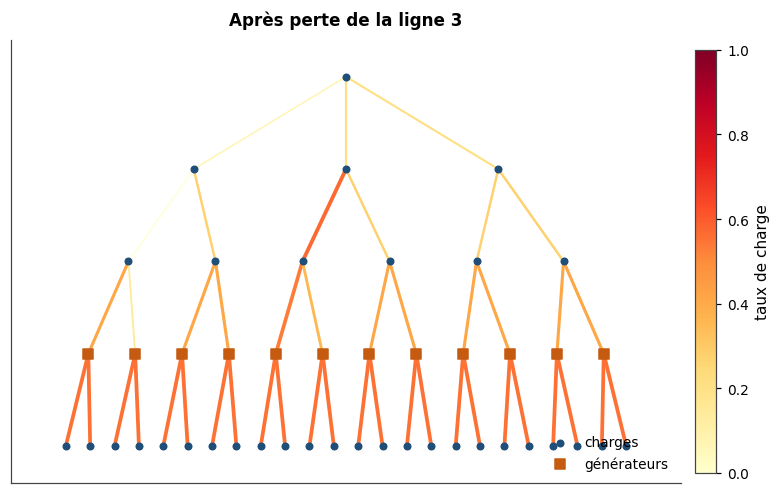

In [13]:
avant = resoudre(reseau, demande_uniforme(reseau, 0.8 * P_C),
                 limites=limites, puissance_max=p_max, A=A)

# On fait tomber la ligne la plus chargée. Une ligne en panne n'est pas retirée du
# réseau : sa réactance est rendue très grande et sa capacité très petite, ce qui
# évite de rendre la matrice singulière.
ligne_perdue = int(np.argmax(avant.taux_de_charge))

reseau_apres = Reseau(
    n_noeuds=reseau.n_noeuds, lignes=reseau.lignes,
    reactances=reseau.reactances.copy(), generateurs=reseau.generateurs,
    charges=reseau.charges, niveaux=reseau.niveaux, reference=reseau.reference,
)
reseau_apres.reactances[ligne_perdue] *= 1e6
limites_apres = limites.copy()
limites_apres[ligne_perdue] *= 1e-6

apres = resoudre(reseau_apres, demande_uniforme(reseau, 0.8 * P_C),
                 limites=limites_apres, puissance_max=p_max)

# La ligne hors service est exclue des statistiques : son taux de charge est le
# rapport de deux quantités quasi nulles et n'a aucun sens physique.
en_service = np.ones(reseau.n_lignes, dtype=bool)
en_service[ligne_perdue] = False

figures.reseau_en_arbre(reseau, taux=np.where(en_service, apres.taux_de_charge, 0.0),
                        titre=f"Après perte de la ligne {ligne_perdue}");

print(f"ligne perdue : {ligne_perdue}, reliant les nœuds {reseau.lignes[ligne_perdue]}")
print(f"délestage    : {avant.delestage_total:.1f}  →  {apres.delestage_total:.1f}")
print(f"M_max        : {avant.taux_maximal:.3f}  →  "
      f"{apres.taux_de_charge[en_service].max():.3f}")
print(f"lignes eff.  : {nombre_effectif(avant.flux):.1f}  →  "
      f"{nombre_effectif(apres.flux[en_service]):.1f}")

**Un piège découvert en écrivant ce carnet.** Le taux de charge de la ligne
morte vaut environ 1 : son flux est quasi nul, sa capacité aussi, et le rapport
de deux quantités quasi nulles ne veut rien dire. Si on l'incluait dans
$M_{\max}$, une ligne en panne apparaîtrait comme saturée en permanence et
serait retenue pour tomber à nouveau à chaque itération de la cascade.

Les lignes hors service doivent donc être suivies explicitement et exclues des
statistiques. C'est une contrainte de conception pour le module `cascade`.

**Et voici une limite du réseau en arbre, qu'il vaut mieux connaître d'avance.**

Dans un arbre, le chemin entre deux nœuds est unique. Perdre une ligne ne
redistribue donc rien : ça isole purement et simplement le sous-arbre situé en
aval, dont toute la charge doit être coupée.

Or la redistribution après avarie est précisément le mécanisme de propagation
d'une cascade dans un réseau maillé. Une cascade dans un arbre n'est donc pas
tout à fait le même phénomène que dans un réseau réel.

Carreras utilise quand même l'arbre, et prend le réseau IEEE 118-bus comme cas
maillé plus réaliste. Ça vaut une phrase dans le rapport d'étape, et ça figure
déjà dans la délimitation du plan de travail comme extension possible.

---
## Où en est le projet

**En place et validé** — les deux modules du fil B, et les deux premiers du fil
A. 105 tests, environ vingt-cinq secondes.

**Reproduit** — la première transition tombe exactement à la capacité de
production, la fraction délestée suit exactement $(r-1)/r$, et le mécanisme de
la seconde transition émerge du modèle sans avoir été programmé.

**Calibré, et signalé comme tel** — l'échelle des capacités de lignes est fixée
pour que la saturation apparaisse au niveau rapporté dans la littérature. Ce
n'est pas une prédiction du modèle.

**Prochains modules** — `cascade`, qui fera tomber les lignes saturées avec une
probabilité $p_1$ et relancera le dispatch en boucle, puis `evolution`, qui
produira enfin les séries temporelles.